<a href="https://colab.research.google.com/github/Nguyencaoquochuy/Nguy-n-Cao-Qu-c-Huy-CS441V-Data-Visualization-/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas requests matplotlib scikit-learn

Dataset updated on disk.

 THỜI ĐIỂM HIỆN TẠI: 2026-03-15 14:42:00
   Mực nước thực tế : 1.427 m
   Gió: 0.7 m/s | Dòng chảy: 0.125 m/s
----------------------------------------
 DỰ BÁO CHO 30 PHÚT TỚI:
   Mực nước dự kiến : 1.346 m
   Xu hướng: GIẢM



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


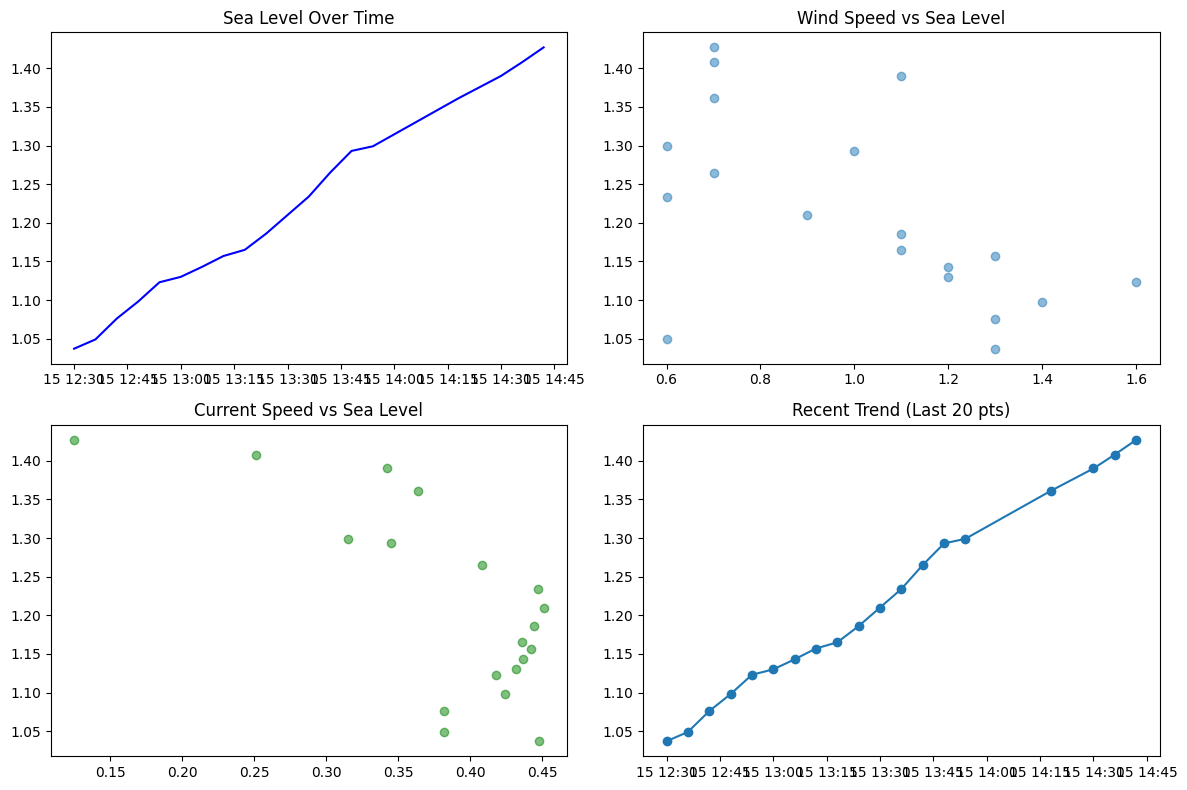


Waiting 360s for next update...
Dataset updated on disk.

 THỜI ĐIỂM HIỆN TẠI: 2026-03-15 14:48:00
   Mực nước thực tế : 1.456 m
   Gió: 0.9 m/s | Dòng chảy: 0.136 m/s
----------------------------------------
 DỰ BÁO CHO 30 PHÚT TỚI:
   Mực nước dự kiến : 1.419 m
   Xu hướng: GIẢM



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


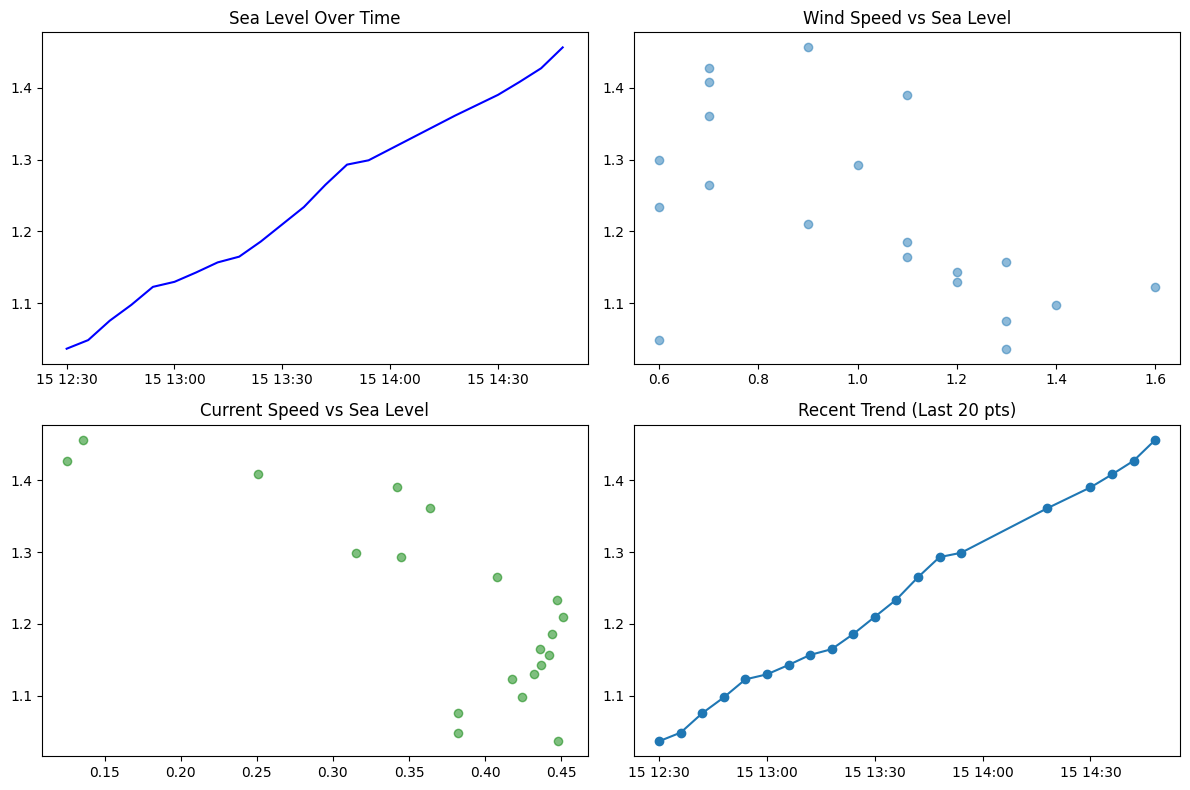


Waiting 360s for next update...


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import matplotlib.dates as mdates
from datetime import timedelta
from sklearn.ensemble import RandomForestRegressor

# ==============================
# CONFIG - Đã sửa ID trạm chuẩn
# ==============================
STATION_WATER_WIND = "9414290"  # San Francisco (Water + Wind)
STATION_CURRENT = "s06010"     # Martinez-AMORCO Pier (Currents)
DATA_FILE = "ocean_dataset.csv"
UPDATE_INTERVAL = 360 # 6 phút

API_URL = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"

# ==============================
# FETCH WATER LEVEL - Lấy điểm mới nhất
# ==============================
def fetch_water_level():
    params = {
        "product": "water_level",
        "station": STATION_WATER_WIND,
        "date": "latest",
        "units": "metric",
        "time_zone": "gmt",
        "datum": "MLLW",  # THÊM DÒNG NÀY ĐỂ FIX LỖI
        "format": "json"
    }
    try:
        r = requests.get(API_URL, params=params, timeout=10)
        data = r.json()
        if "data" in data:
            row = data["data"][0]
            return {"time": row["t"], "water_level": float(row["v"]) }
        else:
            # Dòng này sẽ in ra lỗi cụ thể nếu vẫn còn trục trặc
            print(f"Water Level API Error: {data}")
    except Exception as e:
        print(f"Water Level Request Error: {e}")
    return None
# ==============================
# FETCH WIND
# ==============================
def fetch_wind():
    params = {
        "product": "wind",
        "station": STATION_WATER_WIND,
        "date": "latest",
        "units": "metric",
        "time_zone": "gmt",
        "format": "json"
    }
    try:
        r = requests.get(API_URL, params=params, timeout=10)
        data = r.json()
        if "data" in data:
            row = data["data"][0]
            return {"wind_speed": float(row["s"]), "wind_dir": float(row["d"]) }
    except Exception as e:
        print(f"Wind Request Error: {e}")
    return None

# ==============================
# FETCH CURRENT - Trạm s06010
# ==============================
def fetch_current():
    params = {
        "product": "currents",
        "station": STATION_CURRENT,
        "date": "latest",
        "units": "metric",
        "time_zone": "gmt",
        "format": "json"
    }
    try:
        r = requests.get(API_URL, params=params, timeout=10)
        data = r.json()
        if "data" in data:
            row = data["data"][0]
            # Chuyển cm/s -> m/s để đồng bộ với gió
            return {"current_speed": float(row["s"]) / 100, "current_dir": float(row["d"]) }
    except Exception as e:
        print(f"Current Request Error: {e}")
    return {"current_speed": 0.0, "current_dir": 0.0}

# ==============================
# FETCH ALL DATA
# ==============================

def fetch_all():
    sea = fetch_water_level()
    wind = fetch_wind()
    current = fetch_current()

    if sea is None or wind is None:
        print("Missing critical data from fetch_all")
        return None

    row = {**sea, **wind, **current}

    df = pd.DataFrame([row])

    df["time"] = pd.to_datetime(df["time"])

    return df

# ==============================
# PIPELINE - Hợp nhất dữ liệu
# ==============================
def run_pipeline():
    new = fetch_all() # Lấy dữ liệu THẬT hiện tại
    if new is None: return

    save_data(new)
    df = load_dataset()

    if df.empty or len(df) < 15:
        print(f"--- Đang thu thập dữ liệu ({len(df)}/15) ---")
        return

    # 1. Train model với cơ chế "nhìn về tương lai"
    model, df_train = train_model(df)

    if model:
        # 2. THỰC HIỆN DỰ ĐOÁN CHO 30 PHÚT TỚI
        # Lấy thông số gió và dòng chảy VỪA MỚI lấy được
        current_features = [[new["wind_speed"].iloc[0], new["current_speed"].iloc[0]]]

        # AI đoán mực nước cho 30 phút sau dựa trên gió/dòng chảy bây giờ
        future_prediction = model.predict(current_features)[0]
        current_actual = new["water_level"].iloc[0]

        print(f"\n" + "="*40)
        print(f" THỜI ĐIỂM HIỆN TẠI: {new['time'].iloc[0]}")
        print(f"   Mực nước thực tế : {current_actual:.3f} m")
        print(f"   Gió: {new['wind_speed'].iloc[0]} m/s | Dòng chảy: {new['current_speed'].iloc[0]} m/s")
        print(f"----------------------------------------")
        print(f" DỰ BÁO CHO 30 PHÚT TỚI:")
        print(f"   Mực nước dự kiến : {future_prediction:.3f} m")
        print(f"   Xu hướng: {'TĂNG' if future_prediction > current_actual else 'GIẢM'}")
        print("="*40 + "\n")

        # Vẽ biểu đồ
        plot_all(df)

def save_data(df):
    if df is None: # Added check for None DataFrame
        return
    if os.path.exists(DATA_FILE):
        old_df = pd.read_csv(DATA_FILE)
        df = pd.concat([old_df, df]).drop_duplicates(subset=["time"])
    df.to_csv(DATA_FILE, index=False)
    print("Dataset updated on disk.")

def load_dataset():
    if not os.path.exists(DATA_FILE): return pd.DataFrame()
    df = pd.read_csv(DATA_FILE)
    df["time"] = pd.to_datetime(df["time"])
    return df

def train_model(df):
    # Chúng ta cần ít nhất 15-20 điểm dữ liệu để dự đoán có ý nghĩa
    if len(df) < 15:
        return None, None

    # Tạo mục tiêu: Mực nước của 30 phút sau (6 phút/mẫu * 5 mẫu = 30 phút)
    # Chúng ta dịch chuyển cột water_level lên trên 5 dòng
    df_train = df.copy()
    df_train['target_water_level'] = df_train['water_level'].shift(-5)

    # Loại bỏ các dòng cuối bị trống do shift
    train_data = df_train.dropna(subset=['target_water_level'])

    X = train_data[["wind_speed", "current_speed"]]
    y = train_data["target_water_level"]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)

    return model, df_train

def plot_all(df):
    plt.close('all') # Đóng các hình cũ để tránh tràn bộ nhớ
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Sea Level
    axes[0,0].plot(df["time"], df["water_level"], color='blue')
    axes[0,0].set_title("Sea Level Over Time")

    # Wind vs Sea
    axes[0,1].scatter(df["wind_speed"], df["water_level"], alpha=0.5)
    axes[0,1].set_title("Wind Speed vs Sea Level")

    # Current vs Sea
    axes[1,0].scatter(df["current_speed"], df["water_level"], color='green', alpha=0.5)
    axes[1,0].set_title("Current Speed vs Sea Level")

    # Trend
    axes[1,1].plot(df["time"].tail(20), df["water_level"].tail(20), marker='o')
    axes[1,1].set_title("Recent Trend (Last 20 pts)")

    plt.tight_layout()
    plt.pause(0.1) # Hiển thị biểu đồ mà không làm treo vòng lặp
    plt.show(block=False)

if __name__ == "__main__":
    while True:
        run_pipeline()
        print(f"\nWaiting {UPDATE_INTERVAL}s for next update...")
        time.sleep(UPDATE_INTERVAL)